In [18]:
# ORAS5 Test
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import gc

import numpy as np
import pandas as pd
import xarray as xr

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print(f"\n{'='*80}\n   1. ORAS5 CONFIGURATION\n{'='*80}")

DATA_DIR = Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\BOXED")

REGION = {
    "lat_min": 0,
    "lat_max": 90,
    "lon_min": -90,
    "lon_max": 10,
}

FILE_RE = re.compile(r"ORAS5_(\d{4})_(\d{2})_(.+?)_boxed\.nc$")


MAX_MONTHS = 120   # 10 years approx (small for testing)
LOOKBACK = 12

VAR_META = {
    "sst": {
        "token": "sst",
        "depth_mode": None,
    },
}

print("ORAS5 directory:", DATA_DIR)
print("Variables:", list(VAR_META.keys()))


   1. ORAS5 CONFIGURATION
ORAS5 directory: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\BOXED
Variables: ['sst']


In [19]:
# Helper funcs
print(f"\n{'='*80}\n   2. HELPER FUNCTIONS\n{'='*80}")

def files_for_token(data_dir, token):
    all_nc = sorted(data_dir.rglob("*.nc"))
    out = [p for p in all_nc if FILE_RE.search(p.name) and token in p.name]
    return sorted(out)


def time_from_filename(path):
    m = FILE_RE.search(path.name)
    if m is None:
        raise ValueError(f"Filename does not match expected pattern: {path.name}")
    year = int(m.group(1))
    month = int(m.group(2))
    return pd.Timestamp(year=year, month=month, day=1)


def find_main_var(ds):
    ignore = {
        "time", "time_counter", "valid_time", "nav_time",
        "lat", "lon", "latitude", "longitude", "nav_lat", "nav_lon",
        "depth", "deptht", "depthu", "depthv", "nav_lev"
    }
    candidates = [k for k in ds.data_vars if k not in ignore]
    if len(candidates) == 0:
        raise ValueError(f"No usable variable found. Available data_vars={list(ds.data_vars)}")
    return candidates[0]


def find_coord_name(ds, options):
    for name in options:
        if name in ds.coords or name in ds.variables:
            return name
    return None


def normalise_longitude(lon):
    return xr.where(lon > 180, lon - 360, lon)


def subset_region(ds, region):
    lat_name = find_coord_name(ds, ["lat", "latitude", "nav_lat"])
    lon_name = find_coord_name(ds, ["lon", "longitude", "nav_lon"])

    if lat_name is None or lon_name is None:
        print("Warning: could not find lat/lon coords; skipping regional subset")
        return ds

    lat = ds[lat_name]
    lon = normalise_longitude(ds[lon_name])

    if lon_name in ds.coords:
        ds = ds.assign_coords({lon_name: lon})

    mask = (
        (lat >= region["lat_min"]) & (lat <= region["lat_max"]) &
        (lon >= region["lon_min"]) & (lon <= region["lon_max"])
    )

    return ds.where(mask, drop=True)


def depth_reduce_if_needed(da, ds, depth_mode):
    if depth_mode is None:
        return da

    for zname in ["depth", "deptht", "depthu", "depthv", "nav_lev"]:
        if zname in da.dims:
            if zname in da.coords:
                z = da[zname]
            elif zname in ds.coords:
                z = ds[zname]
            elif zname in ds.variables:
                z = ds[zname]
            else:
                z = xr.DataArray(np.arange(da.sizes[zname]), dims=[zname])

            if depth_mode == "0_100m":
                return da.where((z >= 0) & (z <= 100), drop=True).mean(dim=zname)

    return da


def clean_oras5_array(da):
    for tdim in ["time_counter", "valid_time", "nav_time", "time"]:
        if tdim in da.dims and da.sizes[tdim] == 1:
            da = da.isel({tdim: 0}, drop=True)

    for bdim in ["bnds", "bounds", "nbnds", "nv"]:
        if bdim in da.dims:
            da = da.isel({bdim: 0}, drop=True)

    da = da.squeeze(drop=True)

    if "y" in da.dims and "x" in da.dims:
        da = da.transpose("y", "x")

    return da.astype(np.float32)


print("Helper functions ready.")


   2. HELPER FUNCTIONS
Helper functions ready.


In [22]:
# Load files into array
print(f"\n{'='*80}\n   3. LOADING MONTHLY ORAS5 VARIABLES\n{'='*80}")

file_dict = {}

for var_name, meta in VAR_META.items():
    paths = files_for_token(DATA_DIR, meta["token"])
    file_dict[var_name] = {time_from_filename(p): p for p in paths}
    print(f"{var_name:12s}: {len(paths)} files")

common_times = sorted(set.intersection(*[set(d.keys()) for d in file_dict.values()]))

if MAX_MONTHS is not None:
    common_times = common_times[:MAX_MONTHS]

print(f"\nCommon monthly timesteps: {len(common_times)}")
print(f"First: {common_times[0]}")
print(f"Last : {common_times[-1]}")

monthly_fields = []
used_times = []

for i, ts in enumerate(common_times, start=1):
    print(f"Loading {i}/{len(common_times)}: {ts.strftime('%Y-%m')}")

    var_arrays = []

    for var_name, meta in VAR_META.items():
        path = file_dict[var_name][ts]

        with xr.open_dataset(path, engine="h5netcdf") as ds:
            ds = subset_region(ds, REGION)
            vname = find_main_var(ds)

            da = ds[vname]
            da = depth_reduce_if_needed(da, ds, meta["depth_mode"])
            da = clean_oras5_array(da)

            var_arrays.append(da.load())

    min_y = min(da.sizes["y"] for da in var_arrays)
    min_x = min(da.sizes["x"] for da in var_arrays)

    var_arrays = [
        da.isel(y=slice(0, min_y), x=slice(0, min_x))
        for da in var_arrays
    ]

    stacked = xr.concat(var_arrays, dim="feature")
    stacked = stacked.assign_coords(feature=list(VAR_META.keys()))

    stacked = stacked.reset_coords(drop=True)

    monthly_fields.append(stacked)
    used_times.append(ts)
    used_times.append(ts)

# Force to sgared grid
global_min_y = min(da.sizes["y"] for da in monthly_fields)
global_min_x = min(da.sizes["x"] for da in monthly_fields)

print(f"Cropping all months to y={global_min_y}, x={global_min_x}")

monthly_fields_fixed = []

for da, ts in zip(monthly_fields, used_times):
    da = da.isel(
        y=slice(0, global_min_y),
        x=slice(0, global_min_x)
    )

    da = da.assign_coords(
        y=np.arange(global_min_y),
        x=np.arange(global_min_x)
    )

    da = da.expand_dims(time=[np.datetime64(ts)])

    monthly_fields_fixed.append(da)

oras5_monthly = xr.concat(
    monthly_fields_fixed,
    dim="time",
    coords="minimal",
    compat="override",
    join="override"
)

oras5_monthly.name = "oras5_multivar"

print("\nFinal ORAS5 monthly tensor:")
print(oras5_monthly)
print("Shape:", oras5_monthly.shape)


   3. LOADING MONTHLY ORAS5 VARIABLES
sst         : 819 files

Common monthly timesteps: 120
First: 1958-01-01 00:00:00
Last : 1967-12-01 00:00:00
Loading 1/120: 1958-01
Loading 2/120: 1958-02
Loading 3/120: 1958-03
Loading 4/120: 1958-04
Loading 5/120: 1958-05
Loading 6/120: 1958-06
Loading 7/120: 1958-07
Loading 8/120: 1958-08
Loading 9/120: 1958-09
Loading 10/120: 1958-10
Loading 11/120: 1958-11
Loading 12/120: 1958-12
Loading 13/120: 1959-01
Loading 14/120: 1959-02
Loading 15/120: 1959-03
Loading 16/120: 1959-04
Loading 17/120: 1959-05
Loading 18/120: 1959-06
Loading 19/120: 1959-07
Loading 20/120: 1959-08
Loading 21/120: 1959-09
Loading 22/120: 1959-10
Loading 23/120: 1959-11
Loading 24/120: 1959-12
Loading 25/120: 1960-01
Loading 26/120: 1960-02
Loading 27/120: 1960-03
Loading 28/120: 1960-04
Loading 29/120: 1960-05
Loading 30/120: 1960-06
Loading 31/120: 1960-07
Loading 32/120: 1960-08
Loading 33/120: 1960-09
Loading 34/120: 1960-10
Loading 35/120: 1960-11
Loading 36/120: 1960-

In [23]:
# Prep data

print(f"\n{'='*80}\n   4. SCALING & SEQUENCE GENERATION\n{'='*80}")

data = oras5_monthly.transpose("time", "y", "x", "feature").values.astype(np.float32)

data[np.abs(data) > 1e10] = np.nan

print("Raw data shape:", data.shape)

means = np.nanmean(data, axis=(0, 1, 2), keepdims=True)
stds = np.nanstd(data, axis=(0, 1, 2), keepdims=True)

data_scaled = (data - means) / (stds + 1e-8)
data_scaled = np.nan_to_num(data_scaled, nan=0.0, posinf=0.0, neginf=0.0)

scaler = {
    "means": means,
    "stds": stds,
    "features": list(VAR_META.keys())
}

X, y = [], []

for i in range(data_scaled.shape[0] - LOOKBACK):
    X.append(data_scaled[i:i+LOOKBACK])
    y.append(data_scaled[i+LOOKBACK])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)

# Chronological split
train_split = int(X.shape[0] * 0.70)
val_split = int(X.shape[0] * 0.85)

X_train, y_train = X[:train_split], y[:train_split]
X_val, y_val = X[train_split:val_split], y[train_split:val_split]
X_test, y_test = X[val_split:], y[val_split:]

target_times = pd.to_datetime(oras5_monthly.time.values)[LOOKBACK:]

train_times = target_times[:train_split]
val_times = target_times[train_split:val_split]
test_times = target_times[val_split:]

print(f"TRAIN: {train_times[0]} to {train_times[-1]}")
print(f"VAL  : {val_times[0]} to {val_times[-1]}")
print(f"TEST : {test_times[0]} to {test_times[-1]}")

gc.collect()


   4. SCALING & SEQUENCE GENERATION
Raw data shape: (120, 522, 363, 1)
X shape: (108, 12, 522, 363, 1)
y shape: (108, 522, 363, 1)
TRAIN: 1958-07-01 00:00:00 to 1961-08-01 00:00:00
VAL  : 1961-08-01 00:00:00 to 1962-04-01 00:00:00
TEST : 1962-04-01 00:00:00 to 1962-12-01 00:00:00


34693

In [24]:
# Small ConvLSTM

print(f"\n{'='*80}\n   5. TRAINING SMALL ORAS5 CONVLSTM\n{'='*80}")

_, time_steps, n_y, n_x, n_features = X_train.shape

model = Sequential([
    ConvLSTM2D(
        8,
        (3, 3),
        padding="same",
        return_sequences=False,
        input_shape=(time_steps, n_y, n_x, n_features)
    ),
    BatchNormalization(),

    Conv2D(
        n_features,
        (3, 3),
        activation="linear",
        padding="same"
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model.summary()

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        verbose=1
    ),
    ModelCheckpoint(
        "best_oras5_multivar_convlstm.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=3,
    batch_size=2,
    callbacks=callbacks,
    verbose=1
)

print("\nProof-of-concept training complete.")


   5. TRAINING SMALL ORAS5 CONVLSTM


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv_lstm2d_2 (ConvLSTM2D)           │ (None, 522, 363, 8)         │           2,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 522, 363, 8)         │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 522, 363, 1)         │              73 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,729 (10.66 KB)

 Trainable params: 2,713 (10.60 KB)

 Non-trainable params: 16 (64.00 B)

Epoch 1/3
38/38 ━━━━━━━━━━━━━━━━━━━━ 35s 864ms/step - loss: 1.2190 - mae: 0.6573 - val_loss: 0.4397 - val_mae: 0.4483 - learning_rate: 0.0010
Epoch 2/3
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 835ms/step - loss: 0.0852 - mae: 0.1648
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
38/38 ━━━━━━━━━━━━━━━━━━━━ 35s 925ms/step - loss: 0.0681 - mae: 0.1483 - val_loss: 0.4661 - val_mae: 0.4689 - learning_rate: 0.0010
Epoch 3/3
38/38 ━━━━━━━━━━━━━━━━━━━━ 35s 918ms/step - loss: 0.0418 - mae: 0.1190 - val_loss: 0.4235 - val_mae: 0.4498 - learning_rate: 5.0000e-04

Proof-of-concept training complete.


In [25]:
# Predictions

print(f"\n{'='*80}\n   6. TEST PREDICTIONS\n{'='*80}")

from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

model = load_model("best_oras5_multivar_convlstm.keras")

y_pred = model.predict(X_test)

y_pred_unscaled = (y_pred * scaler["stds"]) + scaler["means"]
y_test_unscaled = (y_test * scaler["stds"]) + scaler["means"]

for i, feature in enumerate(scaler["features"]):
    truth = y_test_unscaled[..., i].flatten()
    pred = y_pred_unscaled[..., i].flatten()

    mask = np.isfinite(truth) & np.isfinite(pred)

    mae = mean_absolute_error(truth[mask], pred[mask])
    rmse = np.sqrt(mean_squared_error(truth[mask], pred[mask]))

    print(f"{feature:12s} | MAE = {mae:.4f} | RMSE = {rmse:.4f}")


   6. TEST PREDICTIONS
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
sst          | MAE = 4.9138 | RMSE = 7.0725


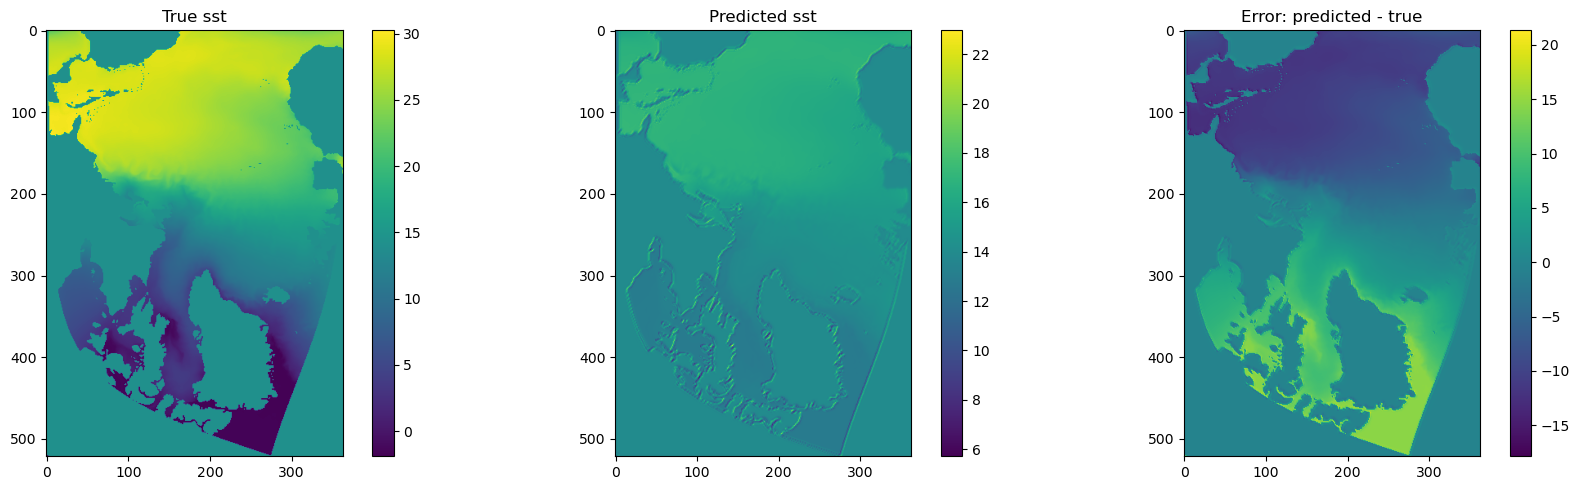

In [26]:
# Plots
sample_idx = 0
feature_name = "sst"
feature_idx = scaler["features"].index(feature_name)

truth = y_test_unscaled[sample_idx, :, :, feature_idx]
pred = y_pred_unscaled[sample_idx, :, :, feature_idx]
error = pred - truth

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(truth)
axes[0].set_title(f"True {feature_name}")

im1 = axes[1].imshow(pred)
axes[1].set_title(f"Predicted {feature_name}")

im2 = axes[2].imshow(error)
axes[2].set_title(f"Error: predicted - true")

plt.colorbar(im0, ax=axes[0], fraction=0.046)
plt.colorbar(im1, ax=axes[1], fraction=0.046)
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()